# Tai Phake Video Dataset Sanity Check

This notebook checks whether your Tai Phake videos are usable for a LipNet-style pipeline.

Goals:

- Can OpenCV read every video?
- Are FPS/resolution consistent?
- Are there corrupted/unreadable frames?
- Can the video be converted to grayscale?
- Can we crop a region without errors?
- Can the frames be normalized like the tutorial?
- Are the resulting frame sequences usable by TensorFlow?

For your Tai Phake dataset, do **not** use the GRID crop coordinates `(190:236, 80:220)` yet.  
Those coordinates were designed for GRID. Use this notebook first to validate the raw videos.


## Cell 1 — Install/import

In [32]:
import os
import cv2
import numpy as np
import tensorflow as tf
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt # to render our post-process output of our data loading function

## Cell 2 — Set your dataset folder

This notebook uses the dataset layout already present in this project:

```text
data/
├── s1/                 # speaker 1
│   ├── d0/d0.mp4       # digit 0
│   ├── d1/d1.mp4       # digit 1
│   └── ...
└── s24/                # speaker 24
    ├── d0/d0.mp4
    └── ...
```

Each video is identified by its parent speaker directory and digit directory. The discovery cell below keeps those labels in the results table.

In [33]:
DATASET_DIR = Path("./data")

VIDEO_EXTENSIONS = {".mp4", ".MP4", ".mov", ".MOV", ".avi", ".AVI", ".mkv", ".MKV"}

# This dataset uses data/<speaker>/<digit>/<digit>.mp4, for example data/s1/d0/d0.mp4.
SPEAKER_DIRS = {"s1", "s24"}
DIGIT_DIRS = {f"d{i}" for i in range(11)}


## Cell 3 — Find all videos

In [34]:
video_files = []

for speaker_dir in sorted(DATASET_DIR.iterdir()):
    if not speaker_dir.is_dir() or speaker_dir.name not in SPEAKER_DIRS:
        continue

    for digit_dir in sorted(speaker_dir.iterdir()):
        if not digit_dir.is_dir() or digit_dir.name not in DIGIT_DIRS:
            continue

        expected_file = digit_dir / f"{digit_dir.name}.mp4"
        if expected_file.is_file():
            video_files.append(expected_file)
        else:
            # Keep support for another video extension while preserving the labels.
            video_files.extend(
                sorted(
                    path for path in digit_dir.iterdir()
                    if path.is_file() and path.suffix in VIDEO_EXTENSIONS
                )
            )

video_files = sorted(video_files)

video_index = pd.DataFrame([
    {
        "file": str(path),
        "speaker": path.parents[1].name,
        "digit": path.parents[0].name,
    }
    for path in video_files
])

print("Dataset folder:", DATASET_DIR.resolve())
print("Total videos found:", len(video_files))
display(video_index.head(20))

Dataset folder: /Users/milinda/ghq/github.com/legion2004/lip-test/data
Total videos found: 13


,file,speaker,digit
0,data/s1/d0/d0.mp4,s1,d0
1,data/s1/d1/d1.mp4,s1,d1
2,data/s24/d0/d0.mp4,s24,d0
3,data/s24/d1/d1.mp4,s24,d1
4,data/s24/d10/d10.mp4,s24,d10
5,data/s24/d2/d2.mp4,s24,d2
6,data/s24/d3/d3.mp4,s24,d3
7,data/s24/d4/d4.mp4,s24,d4
8,data/s24/d5/d5.mp4,s24,d5
9,data/s24/d6/d6.mp4,s24,d6


> If this prints something like `Total videos found: 120` and lists paths, the notebook has found your videos.

## Cell 4 — Check basic video properties

In [35]:
results = []

for path in video_files:
    cap = cv2.VideoCapture(str(path))

    opened = cap.isOpened()
    metadata = {
        "file": str(path),
        "speaker": path.parents[1].name,
        "digit": path.parents[0].name,
    }

    if not opened:
        results.append({
            **metadata,
            "readable": False,
            "fps": None,
            "width": None,
            "height": None,
            "frames": None,
            "duration": None,
            "error": "Could not open video"
        })
        cap.release()
        continue

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    duration = frame_count / fps if fps > 0 else None

    results.append({
        **metadata,
        "readable": True,
        "fps": fps,
        "width": width,
        "height": height,
        "frames": frame_count,
        "duration": duration,
        "error": ""
    })

    cap.release()

df = pd.DataFrame(results)
df.head()

Task was destroyed but it is pending!
task: <Task pending name='Task-256' coro=<_async_in_context.<locals>.run_in_context() done, defined at /Users/milinda/ghq/github.com/legion2004/lip-test/.venv/lib/python3.12/site-packages/ipykernel/utils.py:57> wait_for=<Task pending name='Task-257' coro=<Kernel.shell_main() running at /Users/milinda/ghq/github.com/legion2004/lip-test/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at /Users/milinda/ghq/github.com/legion2004/lip-test/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py:564]>
/Users/milinda/.local/share/uv/python/cpython-3.12.13-macos-aarch64-none/lib/python3.12/collections/__init__.py:449: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  result = tuple_new(cls, iterable)
Task was destroyed but it is pending!
task: <Task pending name='Task-257' coro=<Kernel.shell_main() running at /Users/milinda/ghq/github.com/legion2

,file,speaker,digit,readable,fps,width,height,frames,duration,error
0,data/s1/d0/d0.mp4,s1,d0,True,30.0,720,1280,33,1.100000,
1,data/s1/d1/d1.mp4,s1,d1,True,30.0,720,1280,32,1.066667,
2,data/s24/d0/d0.mp4,s24,d0,True,30.0,720,1280,30,1.000000,
3,data/s24/d1/d1.mp4,s24,d1,True,30.0,720,1280,31,1.033333,
4,data/s24/d10/d10.mp4,s24,d10,True,30.0,720,1280,30,1.000000,


## Cell 5 — Look for problems

In [36]:
print("Total videos:", len(df))
print("Readable videos:", df["readable"].sum())
print("Unreadable videos:", (~df["readable"]).sum())

print("\nFPS:")
print(df["fps"].value_counts().head(20))

print("\nResolutions:")
print(df[["width", "height"]].value_counts().head(20))

print("\nDuration statistics:")
print(df["duration"].describe())


Total videos: 13
Readable videos: 13
Unreadable videos: 0

FPS:
fps
30.0    13
Name: count, dtype: int64

Resolutions:
width  height
720    1280      13
Name: count, dtype: int64

Duration statistics:
count    13.000000
mean      1.076923
std       0.099429
min       0.933333
25%       1.033333
50%       1.033333
75%       1.100000
max       1.300000
Name: duration, dtype: float64


> Ideally you see something like:
- FPS: mostly `30.0`
- Resolution: mostly `1280 x 720`

Small differences aren't automatically fatal, but consistency is preferable.

## Cell 6 — Find unusual videos

In [37]:
print("Videos that are NOT 30 FPS:")
display(df[(df["fps"] < 29.5) | (df["fps"] > 30.5)][
    ["file", "fps", "width", "height", "duration"]
])

print("\nVideos that are NOT 1280x720:")
display(df[(df["width"] != 1280) | (df["height"] != 720)][
    ["file", "fps", "width", "height", "duration"]
])


Videos that are NOT 30 FPS:


,file,fps,width,height,duration



Videos that are NOT 1280x720:


,file,fps,width,height,duration
0,data/s1/d0/d0.mp4,30.0,720,1280,1.100000
1,data/s1/d1/d1.mp4,30.0,720,1280,1.066667
2,data/s24/d0/d0.mp4,30.0,720,1280,1.000000
3,data/s24/d1/d1.mp4,30.0,720,1280,1.033333
4,data/s24/d10/d10.mp4,30.0,720,1280,1.000000
5,data/s24/d2/d2.mp4,30.0,720,1280,1.300000
6,data/s24/d3/d3.mp4,30.0,720,1280,0.933333
7,data/s24/d4/d4.mp4,30.0,720,1280,1.233333
8,data/s24/d5/d5.mp4,30.0,720,1280,1.100000
9,data/s24/d6/d6.mp4,30.0,720,1280,1.133333


> This doesn't mean those videos are unusable; it just flags them.

## Cell 7 — Actually read every frame

In [38]:
frame_test_results = []

for path in video_files:

    cap = cv2.VideoCapture(str(path))

    if not cap.isOpened():
        frame_test_results.append({
            "file": str(path),
            "frames_expected": 0,
            "frames_read": 0,
            "bad_frames": 0
        })
        continue

    expected = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    read_count = 0
    bad_frames = 0

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        if frame is None or frame.size == 0:
            bad_frames += 1
        else:
            read_count += 1

    cap.release()

    frame_test_results.append({
        "file": str(path),
        "frames_expected": expected,
        "frames_read": read_count,
        "bad_frames": bad_frames
    })

frame_df = pd.DataFrame(frame_test_results)

frame_df.head()


,file,frames_expected,frames_read,bad_frames
0,data/s1/d0/d0.mp4,33,33,0
1,data/s1/d1/d1.mp4,32,32,0
2,data/s24/d0/d0.mp4,30,30,0
3,data/s24/d1/d1.mp4,31,31,0
4,data/s24/d10/d10.mp4,30,30,0


In [39]:
print("Videos with bad frames:")
display(frame_df[frame_df["bad_frames"] > 0])

print("\nVideos where expected/read frame counts differ:")
display(
    frame_df[
        frame_df["frames_expected"] != frame_df["frames_read"]
    ]
)


Videos with bad frames:


,file,frames_expected,frames_read,bad_frames



Videos where expected/read frame counts differ:


,file,frames_expected,frames_read,bad_frames


> If both tables are empty, that's a good sign.

## Cell 8 — Test the actual preprocessing

Now imitate the important part of the tutorial:

- Video → frames
- BGR → RGB
- RGB → grayscale
- Normalization
- TensorFlow tensor


In [40]:
def test_load_video(path):
    cap = cv2.VideoCapture(str(path))

    if not cap.isOpened():
        raise RuntimeError(f"Could not open: {path}")

    frames = []

    while True:
        ret, frame = cap.read()

        if not ret:
            break

        # OpenCV gives BGR
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        # Convert to grayscale
        frame = cv2.cvtColor(frame, cv2.COLOR_RGB2GRAY)

        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        raise RuntimeError(f"No frames found: {path}")

    # Convert to TensorFlow tensor
    frames = tf.convert_to_tensor(frames, dtype=tf.float32)

    # Normalize like the tutorial
    mean = tf.reduce_mean(frames)
    std = tf.math.reduce_std(frames)

    # Avoid division by zero
    if float(std) == 0:
        raise RuntimeError(f"Standard deviation is zero: {path}")

    frames = (frames - mean) / std

    return frames


## Cell 9 — Test one video

In [41]:
if not video_files:
    raise RuntimeError(
        "No videos found. Expected files such as data/s1/d0/d0.mp4."
    )

test_file = video_files[0]

frames = test_load_video(test_file)

print("File:", test_file)
print("Speaker:", test_file.parents[1].name)
print("Digit:", test_file.parents[0].name)
print("Shape:", frames.shape)
print("dtype:", frames.dtype)
print("min:", tf.reduce_min(frames).numpy())
print("max:", tf.reduce_max(frames).numpy())
print("mean:", tf.reduce_mean(frames).numpy())
print("std:", tf.math.reduce_std(frames).numpy())

File: data/s1/d0/d0.mp4
Speaker: s1
Digit: d0
Shape: (33, 1280, 720)
dtype: <dtype: 'float32'>
min: -2.3631063
max: 1.8546492
mean: -3.2392816e-07
std: 1.0000002


> For a 3‑second, 30 FPS video, you might see something like:
- `Shape: (90, 720, 1280)`
- `dtype: float32`

That means 90 frames, 720 height, 1280 width, and preprocessing worked.

## Cell 10 — Test a smaller mouth crop (manual)

Since you don't want to use the GRID coordinates yet, first check whether cropping works at all.

1. Display a frame.
2. Visually estimate where the mouth is.
3. Choose rough coordinates based on your recording setup.

Do **not** use the example numbers blindly; adjust them after looking at your own frames.


Using frame: 32
Frame shape: (1280, 720)


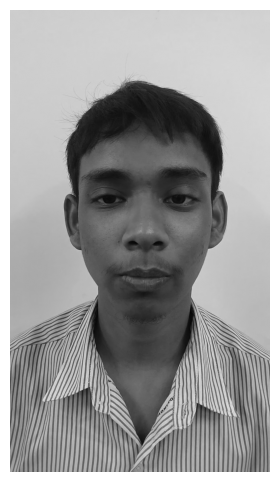

In [42]:
frame_index = min(40, frames.shape[0] - 1)
frame = frames[frame_index].numpy()

print("Using frame:", frame_index)
print("Frame shape:", frame.shape)

plt.figure(figsize=(12, 6))
plt.imshow(frame, cmap="gray")
plt.axis("off");

> Look at where the mouth is, then choose coordinates.
Example (just an example):
- `x = 450 to 830`
- `y = 300 to 600`

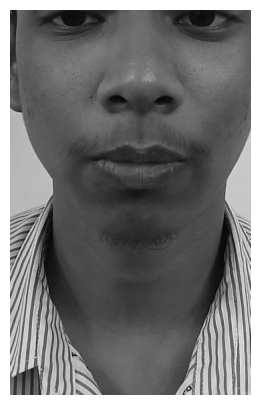

In [43]:
# Continue Cell 10 — try a proportional example crop
# Adjust these after inspecting the displayed frame.
frame_height, frame_width = frame.shape
Y1 = int(frame_height * 0.40)
Y2 = int(frame_height * 0.85)
X1 = int(frame_width * 0.25)
X2 = int(frame_width * 0.75)

cropped = frame[Y1:Y2, X1:X2]

plt.figure(figsize=(10, 5))
plt.imshow(cropped, cmap="gray")
plt.axis("off");

## Cell 11 — Test the crop on the whole video

In [44]:
# Cell 11 — Test the crop on the whole video
# Use the same proportional crop as Cell 10.
frame_height, frame_width = frames.shape[1:]
Y1 = int(frame_height * 0.40)
Y2 = int(frame_height * 0.85)
X1 = int(frame_width * 0.25)
X2 = int(frame_width * 0.75)

cropped_frames = frames[:, Y1:Y2, X1:X2]

print("Original shape:")
print(frames.shape)

print("\nCropped shape:")
print(cropped_frames.shape)

Original shape:
(33, 1280, 720)

Cropped shape:
(33, 576, 360)


> You want something like:
- Original: `(90, 720, 1280)`
- Cropped: `(90, 300, 380)`

That means every frame successfully received the crop.

## Cell 12 — Test the entire dataset

In [45]:
test_results = []

for path in video_files:

    try:
        frames = test_load_video(path)

        test_results.append({
            "file": str(path),
            "status": "OK",
            "frames": frames.shape[0],
            "height": frames.shape[1],
            "width": frames.shape[2],
            "dtype": str(frames.dtype),
            "message": ""
        })

    except Exception as e:

        test_results.append({
            "file": str(path),
            "status": "ERROR",
            "frames": None,
            "height": None,
            "width": None,
            "dtype": None,
            "message": str(e)
        })

test_df = pd.DataFrame(test_results)

display(test_df)


,file,status,frames,height,width,dtype,message
0,data/s1/d0/d0.mp4,OK,33,1280,720,<dtype: 'float32'>,
1,data/s1/d1/d1.mp4,OK,32,1280,720,<dtype: 'float32'>,
2,data/s24/d0/d0.mp4,OK,30,1280,720,<dtype: 'float32'>,
3,data/s24/d1/d1.mp4,OK,31,1280,720,<dtype: 'float32'>,
4,data/s24/d10/d10.mp4,OK,30,1280,720,<dtype: 'float32'>,
5,data/s24/d2/d2.mp4,OK,39,1280,720,<dtype: 'float32'>,
6,data/s24/d3/d3.mp4,OK,28,1280,720,<dtype: 'float32'>,
7,data/s24/d4/d4.mp4,OK,37,1280,720,<dtype: 'float32'>,
8,data/s24/d5/d5.mp4,OK,33,1280,720,<dtype: 'float32'>,
9,data/s24/d6/d6.mp4,OK,34,1280,720,<dtype: 'float32'>,


In [46]:
print("Successful:", (test_df["status"] == "OK").sum())
print("Failed:", (test_df["status"] == "ERROR").sum())

print("\nFailed videos:")
display(test_df[test_df["status"] == "ERROR"])


Successful: 13
Failed: 0

Failed videos:


,file,status,frames,height,width,dtype,message


## What this tells you

If most/all videos pass:

- OpenCV can read them.
- Frames can be decoded.
- Grayscale conversion and normalization work.
- TensorFlow can handle the resulting tensors.

Then you can say:

> The raw Tai Phake videos can be successfully decoded and converted into normalized frame sequences compatible with the preprocessing stage of the LipNet-style pipeline.

This does **not** yet prove the videos are suitable for training, because you still need to solve the most important Tai Phake–specific issue:

> Automatically locating and cropping the mouth consistently across speakers.

Suggested testing order for your project:

1. RAW Tai Phake videos  
2. Can OpenCV read them?  
3. FPS/resolution consistent?  
4. Can every frame be decoded?  
5. Can TensorFlow convert/normalize them?  
6. Can we reliably detect/crop the mouth?  
7. Are sequence lengths manageable?  
8. Only then → model training

You can keep this as a separate `data_test.ipynb` and run it without touching your training notebook.
